# Linear Regression Pairs Trading

Modular pairs-trading backtest powered by `linear_regression/`.
All strategy logic, metrics, and Monte Carlo live in the module — the notebook is a thin orchestration layer.

**Module layout**
```
linear_regression/
├── data_loader.py   load stock CSVs, merge pairs, read ranked-pair CSVs
├── strategy.py      cointegration, hedge ratio, signals, backtest, buy-and-hold
├── metrics.py       Sharpe, max-drawdown, win-rate helpers
├── monte_carlo.py   MC simulation + 3σ outperformance test vs buy-and-hold
└── run_pair.py      CLI entry point (run any pair or top-N from CSV)
```

In [66]:
import sys, os, warnings
warnings.filterwarnings('ignore')

# Make the linear_regression package importable from this notebook
_MODULE_DIR = os.path.abspath('.')          # notebook/spread_models/
sys.path.insert(0, _MODULE_DIR)

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from linear_regression.data_loader  import load_pair, load_pairs_csv
from linear_regression.strategy     import run_backtest, buy_and_hold
from linear_regression.metrics      import print_metrics
from linear_regression.monte_carlo  import (
    simulate_paths, test_3sigma_vs_bnh,
    print_3sigma_report, plot_mc_comparison, plot_realized_vs_bnh,
)

## Configuration

Change `TICKER1` / `TICKER2` to any pair in the ranked CSVs, or point `PAIRS_CSV` at the ranked file and set `TOP_N` to sweep multiple pairs.

In [67]:
# Pair source
DATASET_DIR = os.path.abspath('../../dataset')
DOCS_DIR    = os.path.abspath('../../docs')

KMEANS_CSV = os.path.join(DATASET_DIR, 'kmeans_pairs_ranked.csv')
DBSCAN_CSV = os.path.join(DATASET_DIR, 'dbscan_pairs_ranked.csv')

# For the single-pair walkthrough (Sections 1-7), pick one CSV and one rank
PAIRS_CSV = KMEANS_CSV   # switch to DBSCAN_CSV to inspect a DBSCAN pair
PAIR_RANK = 0            # 0-indexed rank to display

# Cointegration filter
# Only backtest pairs confirmed cointegrated on the training window (p < COINT_ALPHA)
COINT_ONLY  = True
COINT_ALPHA = 0.05

# Date windows
# Aligned with the clustering feature window (2015-2017) so cointegration
# relationships identified during clustering are actually testable here.
# Train: 2015-01-01 to 2016-06-30  (~18 months)
# OOS test: 2016-07-01 to 2017-11-10 (~16 months)
TRAIN_START = '2015-01-01'
TRAIN_END   = '2016-06-30'
TEST_END    = '2017-11-10'

# Strategy hyperparameters
WINDOW  = 30      # rolling z-score window (days)
ENTRY_Z = 1.0     # open position when |z| > ENTRY_Z
EXIT_Z  = 0.25    # close position when |z| < EXIT_Z
TC      = 0.0001  # 1 bp round-trip transaction cost

# Monte Carlo
N_SIMS = 1_000
N_DAYS = 252

DATA_DIR = DATASET_DIR
TOP_N    = 999   # sweep all pairs in each CSV (capped by actual CSV length)


## 1. Load Pair from Ranked CSV

In [68]:
pairs_df = load_pairs_csv(PAIRS_CSV)
row      = pairs_df.iloc[PAIR_RANK]
TICKER1  = row['stock_1']
TICKER2  = row['stock_2']

print(f'Source CSV  : {os.path.basename(PAIRS_CSV)}')
print(f'Rank        : #{int(row["rank"])}')
print(f'Pair        : {TICKER1.upper()} / {TICKER2.upper()}')
if 'cluster' in row:
    print(f'Cluster     : {row["cluster"]}')
if 'correlation' in row:
    print(f'Correlation : {row["correlation"]:.4f}')
if 'half_life' in row:
    print(f'Half-life   : {row["half_life"]:.1f} days')
print()

pair_df = load_pair(TICKER1, TICKER2, DATA_DIR)
print(f'Total rows  : {len(pair_df)}')
print(f'Date range  : {pair_df.Date.min().date()} → {pair_df.Date.max().date()}')
pair_df.head()

Source CSV  : kmeans_pairs_ranked.csv
Rank        : #1
Pair        : HON / UPS
Cluster     : 21
Correlation : 0.6226
Half-life   : 39.8 days

Total rows  : 4526
Date range  : 1999-11-10 → 2017-11-10


,Date,Close_HON,Log_Close_HON,Close_UPS,Log_Close_UPS
0,1999-11-10,49.218,3.896259,53.590,3.981362
1,1999-11-11,48.590,3.883418,58.893,4.075722
2,1999-11-12,50.850,3.928880,55.361,4.013875
3,1999-11-15,51.219,3.936111,54.182,3.992349
4,1999-11-17,51.254,3.936794,53.158,3.973269


## 2. Backtest

`run_backtest` handles the full pipeline in one call:
- ADF stationarity + Engle-Granger cointegration on training data
- OLS hedge ratio fit (training only — no look-ahead bias)
- Spread → rolling z-score → causal position state machine
- Strategy returns with transaction costs → cumulative wealth
- Separate out-of-sample evaluation using the same hedge ratio

In [69]:
bt = run_backtest(
    pair_df, TICKER1, TICKER2,
    train_start=TRAIN_START, train_end=TRAIN_END, test_end=TEST_END,
    window=WINDOW, entry_z=ENTRY_Z, exit_z=EXIT_Z, tc=TC,
)

pair_label = f'{TICKER1.upper()} / {TICKER2.upper()}'
train_df   = bt['train']['df']
test_df    = bt['test']['df'] if bt['test'] else None
col1, col2 = bt['col1'], bt['col2']

# Cointegration summary
c = bt['coint']
print(f'Pair: {pair_label}')
print(f'  ADF {TICKER1.upper()}: stat={c["adf_stat_1"]:.4f}  p={c["adf_pval_1"]:.4f}')
print(f'  ADF {TICKER2.upper()}: stat={c["adf_stat_2"]:.4f}  p={c["adf_pval_2"]:.4f}')
print(f'  Coint  t={c["coint_stat"]:.4f}  p={c["coint_pval"]:.4f}  '
      f'{"COINTEGRATED ✓" if c["cointegrated"] else "NOT cointegrated ✗"}')
print(f'\nHedge ratio β={bt["beta"]:.4f}  α={bt["alpha"]:.4f}  R²={bt["r2"]:.4f}')

Pair: HON / UPS
  ADF HON: stat=-1.6359  p=0.4644
  ADF UPS: stat=-2.4325  p=0.1328
  Coint  t=-2.7812  p=0.1717  NOT cointegrated ✗

Hedge ratio β=0.4507  α=2.4683  R²=0.3637


## 3. Performance Metrics

In [70]:
print_metrics(bt['train']['metrics'])
if bt['test']:
    print()
    print_metrics(bt['test']['metrics'])

  HON/UPS — Training (2015–2016)
  Cumulative Return  :   -12.11%
  Sharpe Ratio       :    -0.86
  Max Drawdown       :   -17.52%
  Win Rate           :     45.3%
  Total Trades       :       23

  HON/UPS — OOS (2017–2017)
  Cumulative Return  :    16.79%
  Sharpe Ratio       :     1.16
  Max Drawdown       :    -4.96%
  Win Rate           :     47.0%
  Total Trades       :       39


## 4. Visualisation — Training Period

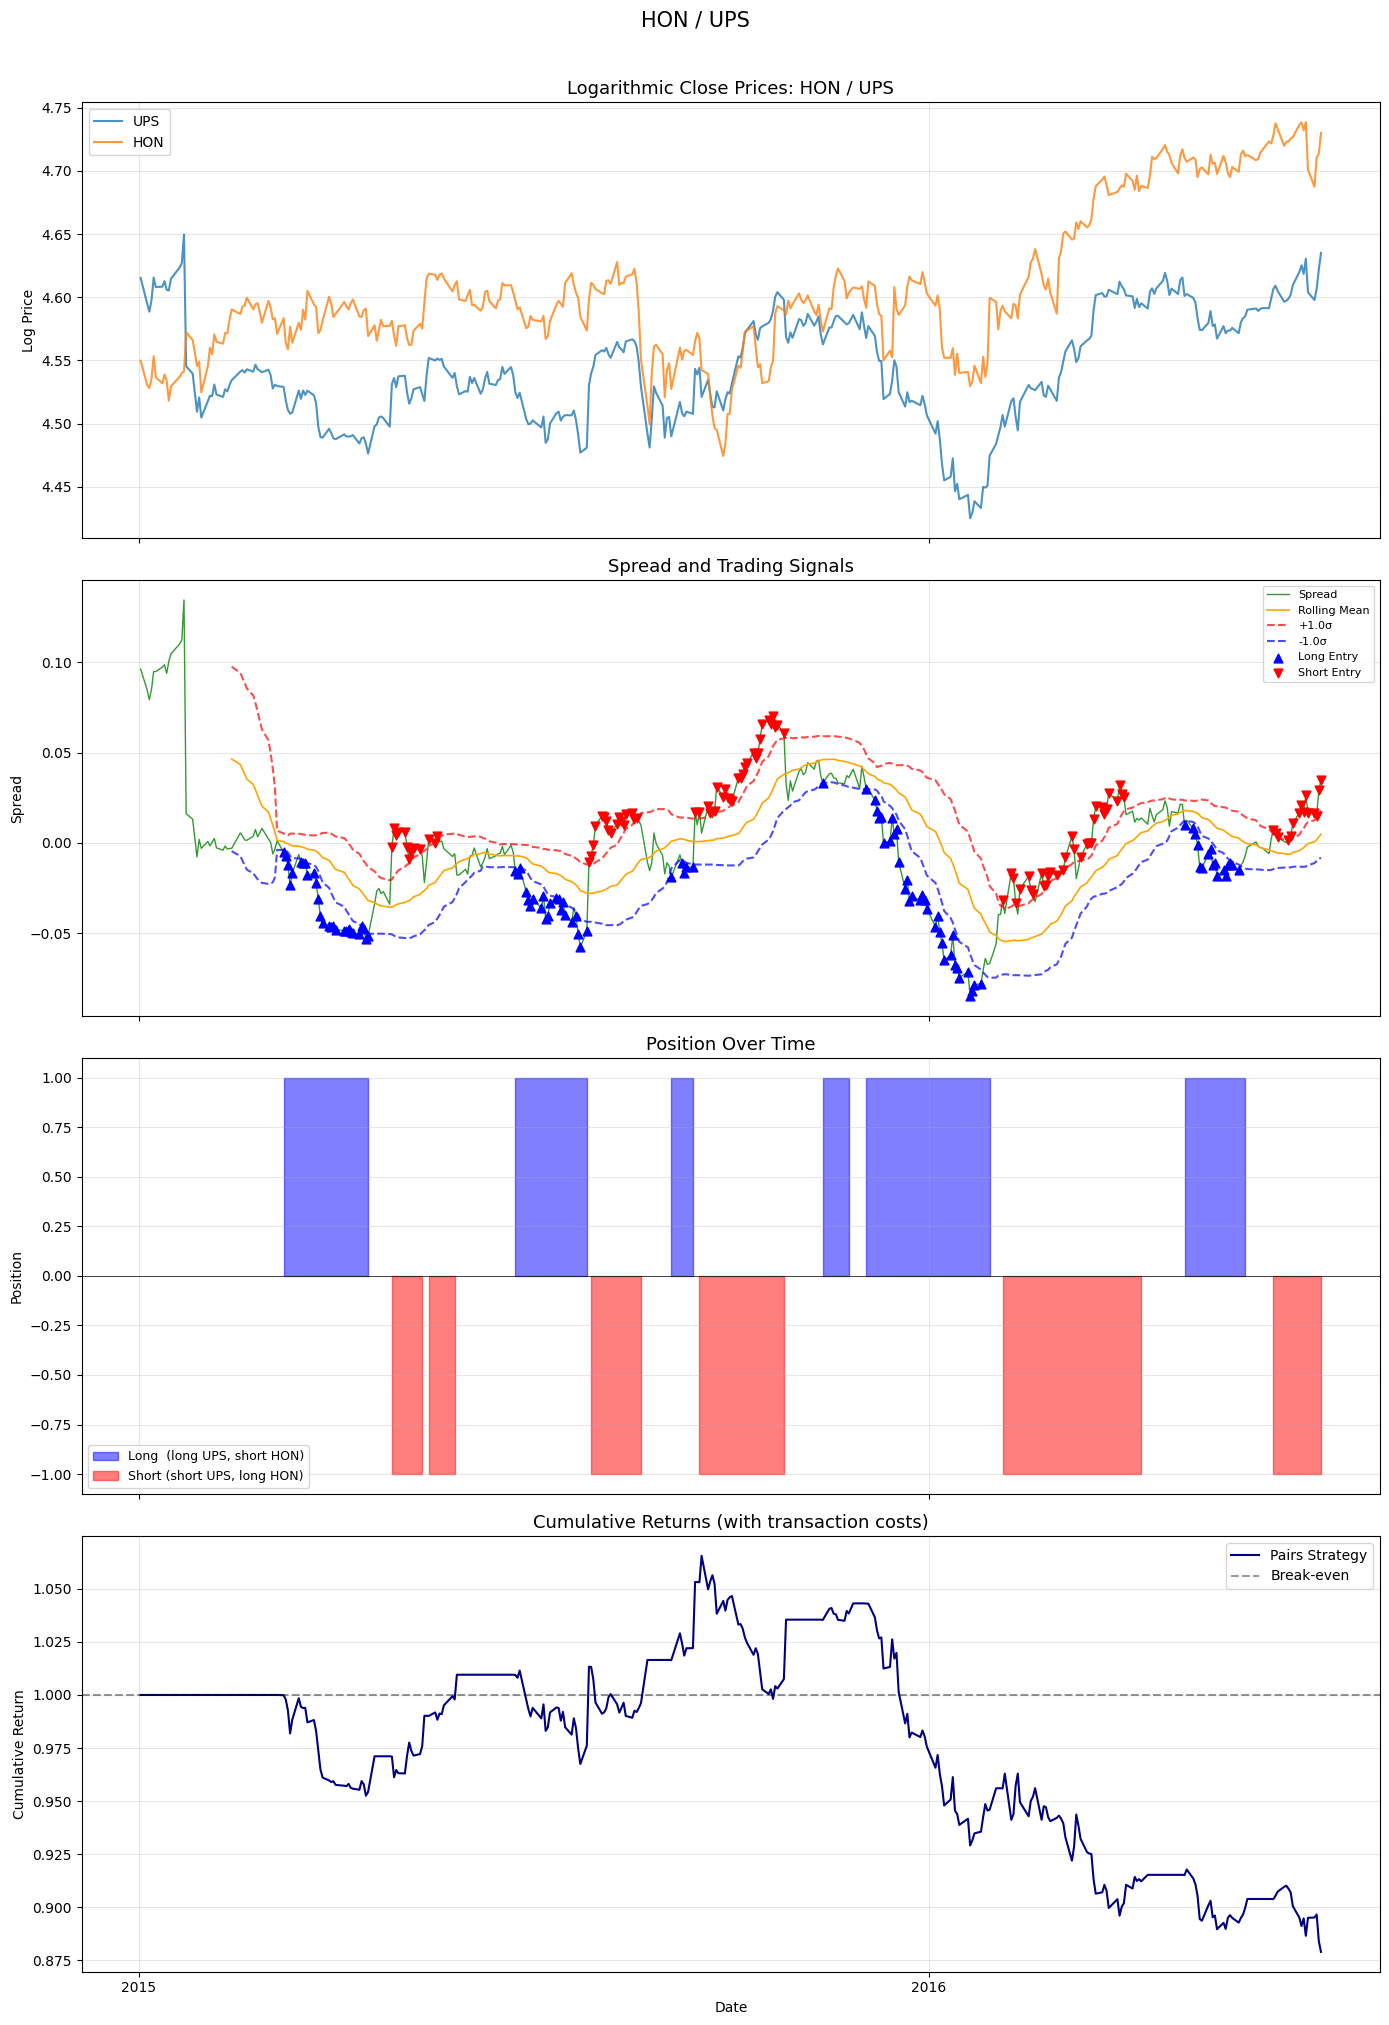

In [71]:
fig, axes = plt.subplots(4, 1, figsize=(14, 20), sharex=True)
pair_label = f'{TICKER1.upper()} / {TICKER2.upper()}'

# Panel 1 — log prices
ax = axes[0]
ax.plot(train_df.Date, train_df[col2], label=TICKER2.upper(), alpha=0.8)
ax.plot(train_df.Date, train_df[col1], label=TICKER1.upper(), alpha=0.8)
ax.set_title(f'Logarithmic Close Prices: {pair_label}', fontsize=13)
ax.set_ylabel('Log Price'); ax.legend(); ax.grid(True, alpha=0.3)

# Panel 2 — spread + z-score bands
long_pts  = train_df[train_df.Z_Score < -ENTRY_Z]
short_pts = train_df[train_df.Z_Score >  ENTRY_Z]
ax = axes[1]
ax.plot(train_df.Date, train_df.Spread,       label='Spread',       color='green', lw=1, alpha=0.8)
ax.plot(train_df.Date, train_df.Rolling_Mean, label='Rolling Mean', color='orange', lw=1.2)
ax.plot(train_df.Date, train_df.Rolling_Mean + ENTRY_Z * train_df.Rolling_Std,
        color='red',  linestyle='--', alpha=0.7, label=f'+{ENTRY_Z}σ')
ax.plot(train_df.Date, train_df.Rolling_Mean - ENTRY_Z * train_df.Rolling_Std,
        color='blue', linestyle='--', alpha=0.7, label=f'-{ENTRY_Z}σ')
ax.scatter(long_pts.Date,  long_pts.Spread,  color='blue', marker='^', s=40, zorder=5, label='Long Entry')
ax.scatter(short_pts.Date, short_pts.Spread, color='red',  marker='v', s=40, zorder=5, label='Short Entry')
ax.set_title('Spread and Trading Signals', fontsize=13)
ax.set_ylabel('Spread'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Panel 3 — positions
ax = axes[2]
ax.fill_between(train_df.Date, train_df.Position, where=train_df.Position > 0,
                alpha=0.5, color='blue', label=f'Long  (long {TICKER2.upper()}, short {TICKER1.upper()})')
ax.fill_between(train_df.Date, train_df.Position, where=train_df.Position < 0,
                alpha=0.5, color='red',  label=f'Short (short {TICKER2.upper()}, long {TICKER1.upper()})')
ax.axhline(0, color='black', lw=0.5)
ax.set_title('Position Over Time', fontsize=13)
ax.set_ylabel('Position'); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# Panel 4 — cumulative return
ax = axes[3]
ax.plot(train_df.Date, train_df.Cum_Return, label='Pairs Strategy', color='navy', lw=1.5)
ax.axhline(1.0, color='black', linestyle='--', alpha=0.4, label='Break-even')
ax.set_title('Cumulative Returns (with transaction costs)', fontsize=13)
ax.set_ylabel('Cumulative Return'); ax.set_xlabel('Date')
ax.legend(); ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.suptitle(pair_label, fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(DOCS_DIR, f'cum_LR_{TICKER1}_{TICKER2}.jpeg'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Out-of-Sample Test

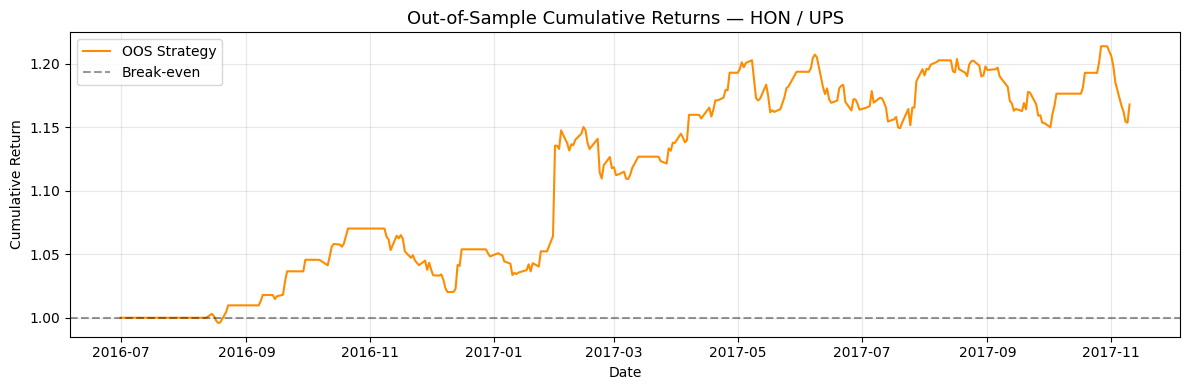

In [72]:
if test_df is not None and len(test_df) > 0:
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(test_df.Date, test_df.Cum_Return, label='OOS Strategy', color='darkorange', lw=1.5)
    ax.axhline(1.0, color='black', linestyle='--', alpha=0.4, label='Break-even')
    ax.set_title(f'Out-of-Sample Cumulative Returns — {pair_label}', fontsize=13)
    ax.set_xlabel('Date'); ax.set_ylabel('Cumulative Return')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print('No out-of-sample data in the current date range.')

## 6. Buy-and-Hold Benchmark

  Buy-and-Hold — Training (2015–2016)
  Cumulative Return  :     8.25%
  Sharpe Ratio       :     0.39
  Max Drawdown       :   -12.49%
  Win Rate           :     52.1%
  Total Trades       :        0

  Buy-and-Hold — OOS
  Cumulative Return  :    17.47%
  Sharpe Ratio       :     1.10
  Max Drawdown       :    -6.65%
  Win Rate           :     54.9%
  Total Trades       :        0


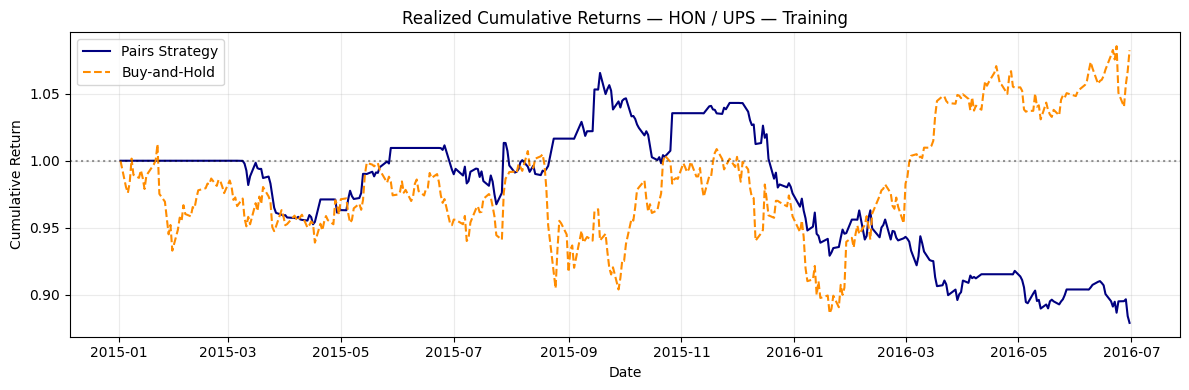

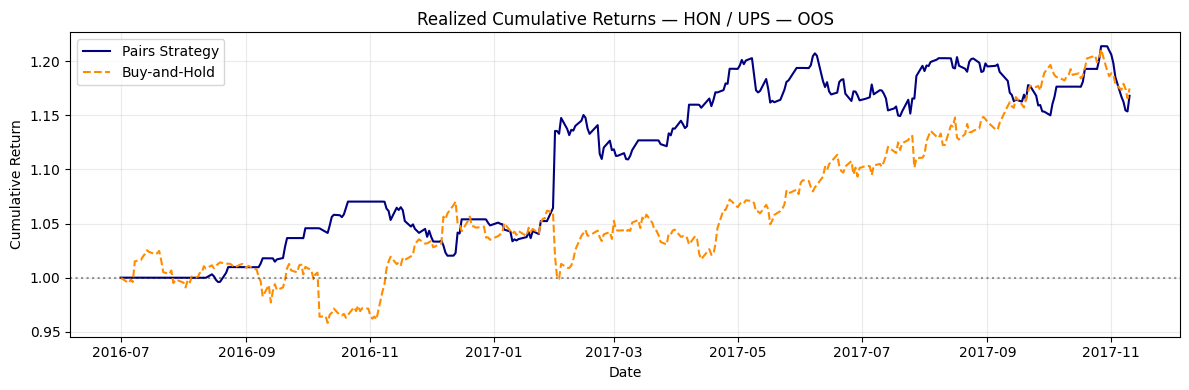

In [73]:
bnh_train = buy_and_hold(train_df, col1, col2, label=f'Buy-and-Hold — Training ({TRAIN_START[:4]}–{TRAIN_END[:4]})')
bnh_test  = buy_and_hold(test_df,  col1, col2, label=f'Buy-and-Hold — OOS') if test_df is not None else None

print_metrics(bnh_train['metrics'])
if bnh_test:
    print(); print_metrics(bnh_test['metrics'])

# Overlay realized returns
plot_realized_vs_bnh(
    train_df, bnh_train['cum_returns'],
    pair_label=f'{pair_label} — Training',
    save_path=os.path.join(DOCS_DIR, f'strategy_vs_bnh_{TICKER1}_{TICKER2}_train.png'),
)
plt.show()

if test_df is not None:
    plot_realized_vs_bnh(
        test_df, bnh_test['cum_returns'],
        pair_label=f'{pair_label} — OOS',
        save_path=os.path.join(DOCS_DIR, f'strategy_vs_bnh_{TICKER1}_{TICKER2}_oos.png'),
    )
    plt.show()

## 7. Monte Carlo — Does the Strategy Beat Buy-and-Hold by 3σ?

Statistical test: is the pairs strategy mean terminal wealth ≥ 3 standard deviations above the buy-and-hold distribution?

```
z = (mean_terminal_strategy − mean_terminal_BnH) / std_terminal_BnH
passes if z ≥ 3
```


  3σ OUTPERFORMANCE TEST — HON / UPS
  Mean terminal wealth (strategy)  : 0.9215
  Mean terminal wealth (BnH)       : 1.0694
  Std of BnH terminal wealth       : 0.1806
  Z-score vs BnH                   : -0.82σ
  3σ threshold                     : FAILS  ✗  (need z≥3, got -0.82)
  P(strategy > BnH median)         : 8.3%
  Welch t-test  t=-23.15, p=0.0000


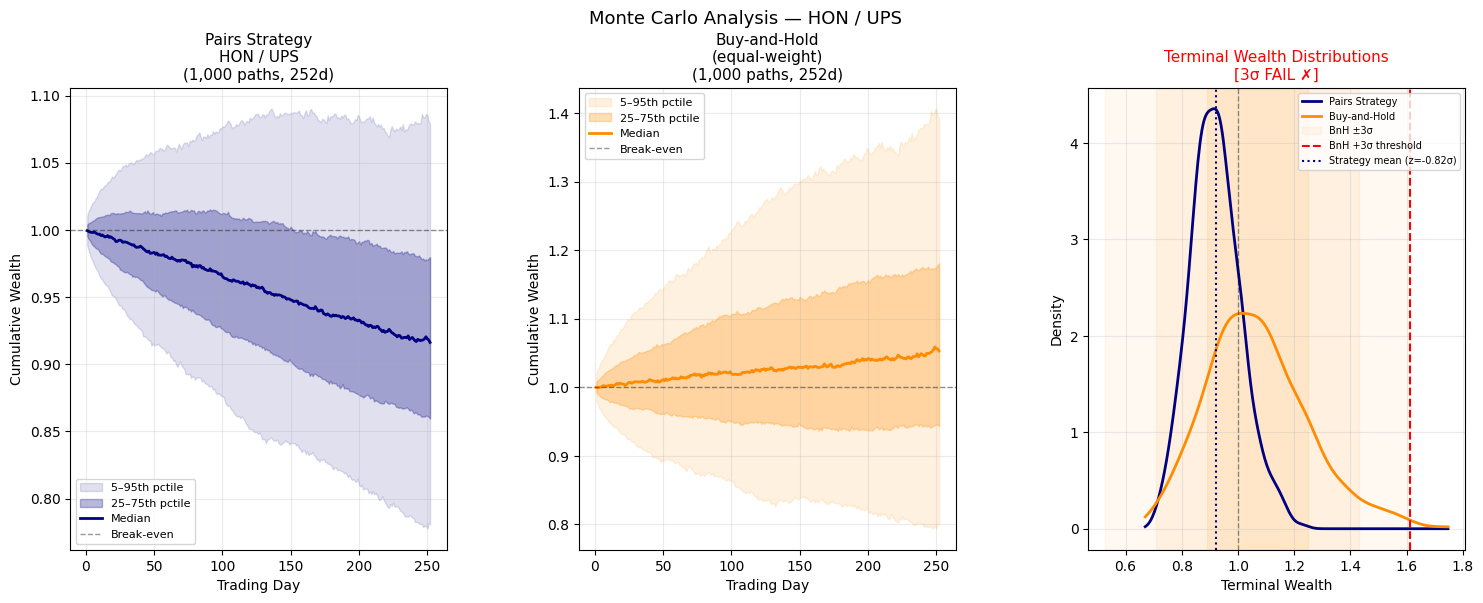

In [74]:
strat_sim  = simulate_paths(train_df['Strategy_Return'].dropna(), n_sims=N_SIMS, n_days=N_DAYS)
bnh_sim    = simulate_paths(bnh_train['returns'].dropna(),        n_sims=N_SIMS, n_days=N_DAYS)
sigma_test = test_3sigma_vs_bnh(strat_sim, bnh_sim)

print_3sigma_report(sigma_test, pair_label)

plot_mc_comparison(
    strat_sim, bnh_sim, sigma_test,
    pair_label=pair_label, n_sims=N_SIMS, n_days=N_DAYS,
    save_path=os.path.join(DOCS_DIR, f'mc_{TICKER1}_{TICKER2}.png'),
)
plt.show()

## 8. Multi-Pair Sweep from Ranked CSV

Iterates the top `TOP_N` pairs from the chosen ranked CSV, runs the full pipeline on each, and prints a summary scoreboard. Pairs that fail data loading or the training window check are skipped.

In [75]:
import pandas as pd

# Build the candidate list from both CSVs
sources = [
    ('K-Means', KMEANS_CSV),
    ('DBSCAN',  DBSCAN_CSV),
]

summary_rows = []
skipped_rows = []

for source_name, csv_path in sources:
    pairs_df = load_pairs_csv(csv_path)
    pairs    = list(zip(pairs_df['stock_1'], pairs_df['stock_2']))[:TOP_N]
    print(f'\n{"─"*64}')
    print(f'  {source_name}  ({len(pairs)} pairs from {os.path.basename(csv_path)})')
    print(f'{"─"*64}')

    for t1, t2 in pairs:
        lbl = f'{t1.upper()}/{t2.upper()}'

        # Load data
        try:
            pf = load_pair(t1, t2, DATA_DIR)
        except FileNotFoundError:
            skipped_rows.append({'source': source_name, 'pair': lbl, 'reason': 'no data'})
            continue

        # Run backtest (runs cointegration test on training window)
        try:
            bt_i = run_backtest(
                pf, t1, t2,
                train_start=TRAIN_START, train_end=TRAIN_END, test_end=TEST_END,
                window=WINDOW, entry_z=ENTRY_Z, exit_z=EXIT_Z, tc=TC,
            )
        except ValueError as e:
            skipped_rows.append({'source': source_name, 'pair': lbl, 'reason': str(e)})
            continue

        coint    = bt_i['coint']
        p_coint  = coint['coint_pval']
        is_coint = coint['cointegrated']

        # Cointegration filter
        if COINT_ONLY and not is_coint:
            skipped_rows.append({
                'source': source_name, 'pair': lbl,
                'reason': f'not cointegrated (p={p_coint:.4f})',
            })
            continue

        # Skip pairs with extreme hedge ratios (|beta| > 5)
        if abs(bt_i['beta']) > 5:
            skipped_rows.append({
                'source': source_name, 'pair': lbl,
                'reason': f'extreme hedge ratio (beta={bt_i["beta"]:.2f})',
            })
            continue

        # Passed all filters — run Monte Carlo
        tdf    = bt_i['train']['df']
        c1, c2 = bt_i['col1'], bt_i['col2']

        bnh_i  = buy_and_hold(tdf, c1, c2)
        ss_i   = simulate_paths(tdf['Strategy_Return'].dropna(), n_sims=N_SIMS, n_days=N_DAYS)
        bs_i   = simulate_paths(bnh_i['returns'].dropna(),       n_sims=N_SIMS, n_days=N_DAYS)
        sig_i  = test_3sigma_vs_bnh(ss_i, bs_i)

        plot_mc_comparison(
            ss_i, bs_i, sig_i,
            pair_label=f'{source_name}: {lbl}', n_sims=N_SIMS, n_days=N_DAYS,
            save_path=os.path.join(DOCS_DIR, f'mc_{t1}_{t2}.png'),
        )
        plt.close('all')

        m     = bt_i['train']['metrics']
        badge = '3sigma PASS' if sig_i['passes_3sigma'] else f'z={sig_i["z_score"]:.2f}'
        print(f'  {lbl:<20}  p={p_coint:.4f}  ret={m["total_return"]:+.1%}  '
              f'sharpe={m["sharpe"]:.2f}  dd={m["max_drawdown"]:.1%}  [{badge}]')

        mt_i = bt_i['test']['metrics'] if bt_i['test'] else None
        summary_rows.append({
            'source':        source_name,
            'pair':          lbl,
            'coint_p':       round(p_coint, 4),
            'beta':          round(bt_i['beta'], 4),
            'train_return':  round(m['total_return'], 4),
            'train_sharpe':  round(m['sharpe'], 2),
            'max_drawdown':  round(m['max_drawdown'], 4),
            'n_trades':      m['n_trades'],
            'bnh_return':    round(bnh_i['metrics']['total_return'], 4),
            'test_return':   round(mt_i['total_return'], 4) if mt_i else None,
            'test_sharpe':   round(mt_i['sharpe'], 2) if mt_i else None,
            'z_score':       round(sig_i['z_score'], 2),
            'passes_3sigma': sig_i['passes_3sigma'],
        })

# Summary scoreboard
print(f'\n{"="*90}')
print('  COINTEGRATED PAIRS — BACKTEST SUMMARY  '
      f'(train: {TRAIN_START} to {TRAIN_END}  |  test: to {TEST_END})')
print(f'{"="*90}')

if summary_rows:
    summary = pd.DataFrame(summary_rows)
    summary = summary.sort_values('train_sharpe', ascending=False)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 130)
    print(summary.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
    n_pass = summary['passes_3sigma'].sum()
    print(f'\n  {len(summary)} cointegrated pairs found.')
    print(f'  {n_pass}/{len(summary)} pass the 3sigma outperformance vs buy-and-hold.')
    print(f'  Median Sharpe : {summary["train_sharpe"].median():.2f}')
    print(f'  Top pair      : {summary.iloc[0]["source"]} {summary.iloc[0]["pair"]}  '
          f'sharpe={summary.iloc[0]["train_sharpe"]:.2f}  return={summary.iloc[0]["train_return"]:+.1%}')
else:
    print('  No cointegrated pairs found.')

# Skipped summary
if skipped_rows:
    skip_df = pd.DataFrame(skipped_rows)
    reasons = skip_df['reason'].str.split('(').str[0].str.strip()
    print(f'\n  {len(skipped_rows)} pairs skipped:')
    for reason, cnt in reasons.value_counts().items():
        print(f'    {cnt:3d}  {reason}')



────────────────────────────────────────────────────────────────
  K-Means  (727 pairs from kmeans_pairs_ranked.csv)
────────────────────────────────────────────────────────────────
  ATRI/CABO             p=0.0455  ret=+19.7%  sharpe=0.83  dd=-12.2%  [z=0.19]
  USB/BP                p=0.0070  ret=+42.5%  sharpe=1.00  dd=-15.7%  [z=1.38]
  USB/FITB              p=0.0074  ret=+24.5%  sharpe=0.93  dd=-13.4%  [z=0.96]
  DVN/APC               p=0.0025  ret=-20.7%  sharpe=-0.53  dd=-30.6%  [z=0.38]
  LPI/SPN               p=0.0144  ret=+5.7%  sharpe=0.30  dd=-34.3%  [z=0.27]
  SPN/HES               p=0.0347  ret=+39.9%  sharpe=0.96  dd=-17.7%  [z=0.82]
  BP/SLB                p=0.0422  ret=+20.0%  sharpe=0.86  dd=-10.8%  [z=0.53]
  AMZN/MKL              p=0.0462  ret=+1.9%  sharpe=0.14  dd=-18.0%  [z=-1.38]
  OBE/MUR               p=0.0451  ret=-64.1%  sharpe=-1.19  dd=-71.1%  [z=-0.32]
  FCNCA/FDX             p=0.0353  ret=+4.9%  sharpe=0.25  dd=-16.6%  [z=0.35]
  LPI/HES               p=

## 9. Sweep Results — Visualisations

Four plots summarising all cointegrated pairs from the Section 8 sweep:
1. **Sharpe bar chart** — all pairs ranked by training Sharpe
2. **Train vs OOS Sharpe scatter** — tests whether train performance generalises
3. **Risk / return scatter** — training return vs max drawdown (bubble = n_trades)
4. **Cumulative returns** — top-5 pairs by training Sharpe over the train window


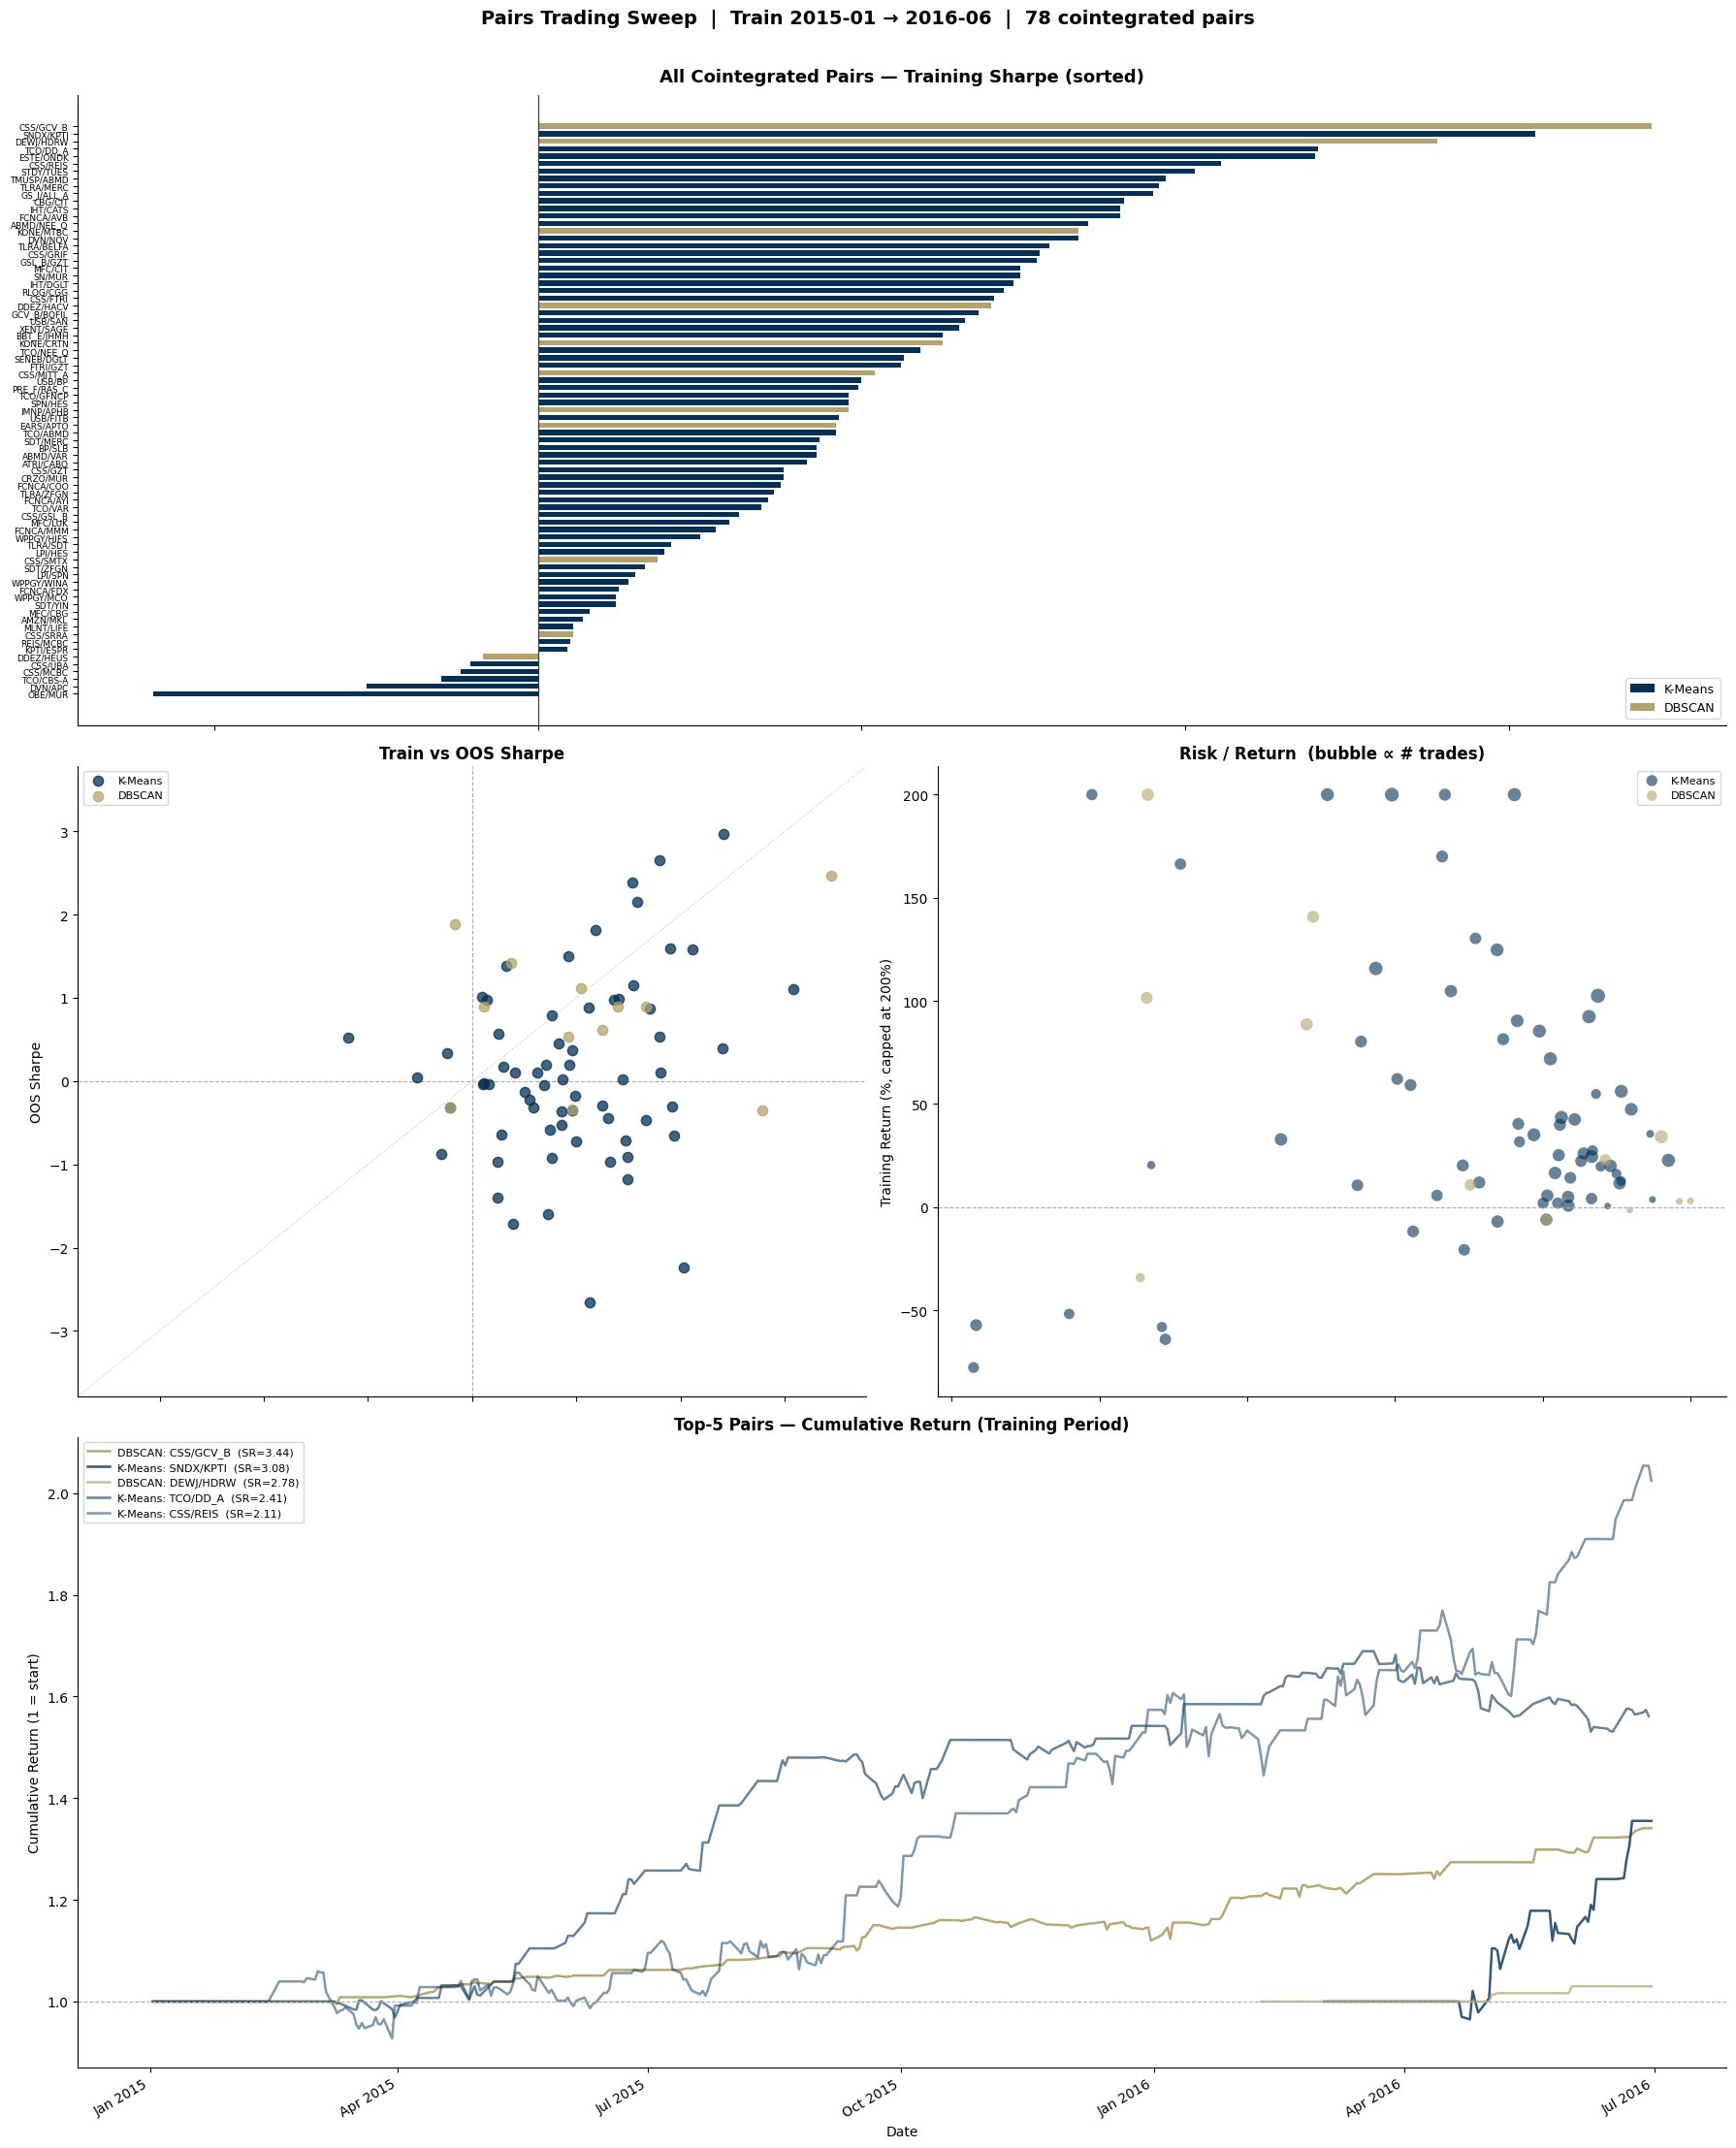

Saved → /Users/wesleylu/Desktop/CS4641/docs/assets/sweep_summary.png


In [76]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
from matplotlib.patches import Patch
import numpy as np
import pandas as pd

if not summary_rows:
    print("No cointegrated pairs found — run Section 8 first.")
else:
    df_plot = pd.DataFrame(summary_rows).sort_values('train_sharpe', ascending=False).reset_index(drop=True)
    COLORS  = {'K-Means': '#003057', 'DBSCAN': '#B3A369'}
    bar_colors = [COLORS.get(s, '#888') for s in df_plot['source']]

    fig = plt.figure(figsize=(18, 22))
    fig.patch.set_facecolor('white')

    # 1. Sharpe bar chart (full top row)
    ax1 = fig.add_subplot(3, 2, (1, 2))
    ax1.barh(df_plot['pair'][::-1], df_plot['train_sharpe'][::-1],
             color=bar_colors[::-1], edgecolor='none', height=0.7)
    ax1.axvline(0, color='#333', linewidth=0.8)
    ax1.set_xlabel('Training Sharpe Ratio', fontsize=11)
    ax1.set_title('All Cointegrated Pairs — Training Sharpe (sorted)', fontsize=13, fontweight='bold', pad=10)
    ax1.tick_params(axis='y', labelsize=6.5)
    ax1.tick_params(axis='x', labelsize=9)
    ax1.spines[['top', 'right']].set_visible(False)
    handles = [Patch(facecolor=COLORS['K-Means'], label='K-Means'),
               Patch(facecolor=COLORS['DBSCAN'],  label='DBSCAN')]
    ax1.legend(handles=handles, fontsize=9, loc='lower right')

    # 2. Train vs OOS Sharpe scatter
    ax2 = fig.add_subplot(3, 2, 3)
    has_test = df_plot['test_sharpe'].notna() if 'test_sharpe' in df_plot.columns else pd.Series(False, index=df_plot.index)
    for src, clr in COLORS.items():
        m = has_test & (df_plot['source'] == src)
        ax2.scatter(df_plot.loc[m, 'train_sharpe'], df_plot.loc[m, 'test_sharpe'],
                    color=clr, alpha=0.75, s=55, label=src, zorder=3)
    lim = max(abs(df_plot.loc[has_test, 'train_sharpe']).max(),
              abs(df_plot.loc[has_test, 'test_sharpe']).max()) * 1.1
    ax2.axhline(0, color='#aaa', linewidth=0.8, linestyle='--')
    ax2.axvline(0, color='#aaa', linewidth=0.8, linestyle='--')
    ax2.plot([-lim, lim], [-lim, lim], color='#ccc', linewidth=0.9, linestyle=':')
    ax2.set_xlim(-lim, lim); ax2.set_ylim(-lim, lim)
    ax2.set_xlabel('Train Sharpe', fontsize=10); ax2.set_ylabel('OOS Sharpe', fontsize=10)
    ax2.set_title('Train vs OOS Sharpe', fontsize=12, fontweight='bold')
    ax2.spines[['top', 'right']].set_visible(False)
    ax2.legend(fontsize=8)

    # 3. Risk / return scatter (cap at 200% for readability)
    ax3 = fig.add_subplot(3, 2, 4)
    ret_cap = df_plot['train_return'].clip(upper=2.0)
    for src, clr in COLORS.items():
        m = df_plot['source'] == src
        ax3.scatter(df_plot.loc[m, 'max_drawdown'] * 100, ret_cap[m] * 100,
                    s=df_plot.loc[m, 'n_trades'] * 1.5 + 20,
                    color=clr, alpha=0.6, edgecolors='none', label=src)
    ax3.axhline(0, color='#aaa', linewidth=0.8, linestyle='--')
    ax3.set_xlabel('Max Drawdown (%)', fontsize=10)
    ax3.set_ylabel('Training Return (%, capped at 200%)', fontsize=10)
    ax3.set_title('Risk / Return  (bubble ∝ # trades)', fontsize=12, fontweight='bold')
    ax3.spines[['top', 'right']].set_visible(False)
    ax3.legend(fontsize=8)

    # 4. Cumulative returns — top-5 (excluding >500% outliers)
    ax4 = fig.add_subplot(3, 2, (5, 6))
    top_plot = df_plot[df_plot['train_return'] <= 5.0].head(5)
    alphas = [0.95, 0.80, 0.70, 0.60, 0.50]
    for j, (_, row) in enumerate(top_plot.iterrows()):
        t1_r, t2_r = row['pair'].split('/')
        try:
            pf_r  = load_pair(t1_r.lower(), t2_r.lower(), DATA_DIR)
            bt_r  = run_backtest(pf_r, t1_r.lower(), t2_r.lower(),
                                 train_start=TRAIN_START, train_end=TRAIN_END, test_end=TEST_END,
                                 window=WINDOW, entry_z=ENTRY_Z, exit_z=EXIT_Z, tc=TC)
            train_df_r = bt_r['train']['df']
            cum = train_df_r.set_index('Date')['Cum_Return'].dropna()
            clr = COLORS.get(row['source'], '#888')
            ax4.plot(cum.index, cum.values,
                     label=f"{row['source']}: {row['pair']}  (SR={row['train_sharpe']:.2f})",
                     linewidth=1.8, color=clr, alpha=alphas[j])
        except Exception:
            continue
    ax4.axhline(1, color='#aaa', linewidth=0.8, linestyle='--')
    ax4.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax4.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax4.set_xlabel('Date', fontsize=10)
    ax4.set_ylabel('Cumulative Return (1 = start)', fontsize=10)
    ax4.set_title('Top-5 Pairs — Cumulative Return (Training Period)', fontsize=12, fontweight='bold')
    ax4.spines[['top', 'right']].set_visible(False)
    ax4.legend(fontsize=8)
    fig.autofmt_xdate(rotation=30, ha='right')

    fig.suptitle(
        f'Pairs Trading Sweep  |  Train {TRAIN_START[:7]} → {TRAIN_END[:7]}'
        f'  |  {len(df_plot)} cointegrated pairs',
        fontsize=14, fontweight='bold', y=1.005
    )
    plt.tight_layout()
    save_path = os.path.join(DOCS_DIR, 'assets', 'sweep_summary.png')
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {save_path}')


## 10. Top-Pair Deep Dive — Buy/Sell Signals & Monte Carlo

Takes the highest-Sharpe pair from the Section 8 sweep and shows:

1. **Buy / Sell signal chart** — green ▲ = open long spread (buy Y / sell X), 
red ▼ = open short spread (sell Y / buy X), grey × = close position.  
Stock prices are shown alongside the spread z-score.
2. **Monte Carlo** — 1,000-path fan chart vs buy-and-hold, plus the 3σ terminal-wealth test.


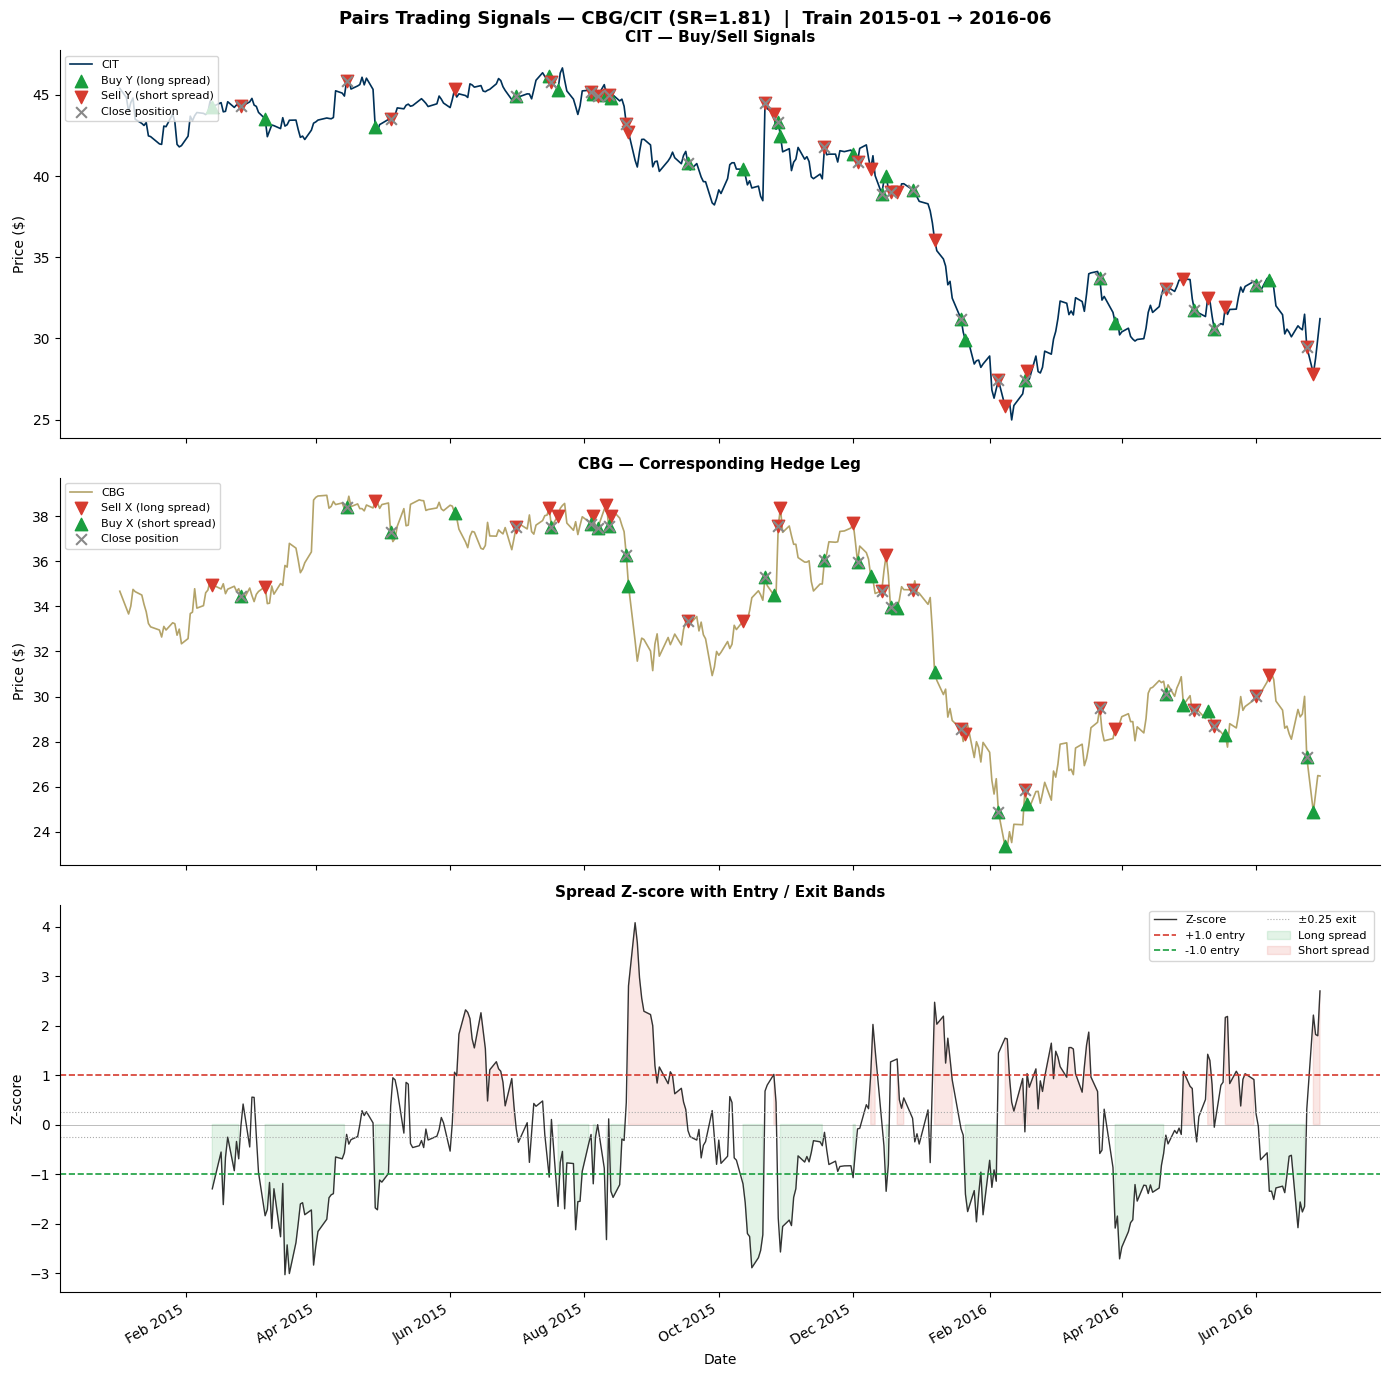

Signals saved → /Users/wesleylu/Desktop/CS4641/docs/assets/signals_cbg_cit.png

  3σ OUTPERFORMANCE TEST — CBG/CIT (SR=1.81)
  Mean terminal wealth (strategy)  : 1.6023
  Mean terminal wealth (BnH)       : 0.8059
  Std of BnH terminal wealth       : 0.2278
  Z-score vs BnH                   : +3.50σ
  3σ threshold                     : PASSES ✓  (strategy is ≥3σ above BnH)
  P(strategy > BnH median)         : 99.9%
  Welch t-test  t=52.28, p=0.0000


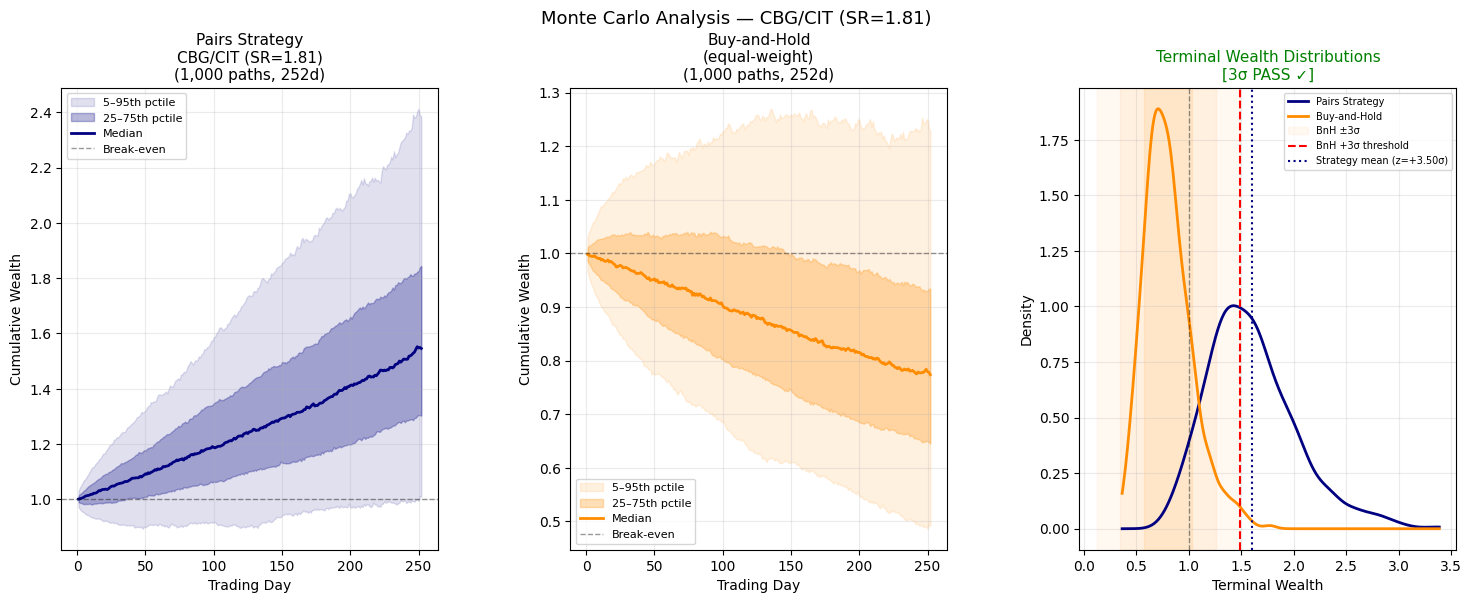

Monte Carlo saved → /Users/wesleylu/Desktop/CS4641/docs/assets/mc_cbg_cit.png


In [79]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import numpy as np

if not summary_rows:
    print("Run Section 8 first.")
else:
    # Use CBG/CIT — cointegrated pair with 3sigma pass
    t1_top, t2_top = 'cbg', 'cit'
    top = next((r for r in summary_rows if r['pair'] == 'CBG/CIT'), None)

    pf_top  = load_pair(t1_top, t2_top, DATA_DIR)
    bt_top  = run_backtest(pf_top, t1_top, t2_top,
                           train_start=TRAIN_START, train_end=TRAIN_END, test_end=TEST_END,
                           window=WINDOW, entry_z=ENTRY_Z, exit_z=EXIT_Z, tc=TC)
    tdf     = bt_top['train']['df'].reset_index(drop=True)
    c1, c2  = bt_top['col1'], bt_top['col2']
    sr      = top['train_sharpe'] if top else bt_top['train']['metrics']['sharpe']
    label   = f"CBG/CIT (SR={sr:.2f})"

    dates   = tdf['Date']
    pos     = tdf['Position'].values
    z       = tdf['Z_Score'].values
    price1  = np.exp(tdf[c1].values)   # back to raw price
    price2  = np.exp(tdf[c2].values)

    # Decode signal transitions (boolean masks — safe with numpy arrays)
    #   +1 = long spread  → long Y (stock2), short X (stock1)
    #   -1 = short spread → short Y, long X
    prev = np.concatenate([[0], pos[:-1]])
    diff = pos - prev

    long_entry_m  = diff ==  1   # open long spread
    short_entry_m = diff == -1   # open short spread
    exit_m        = (prev != 0) & (pos == 0)   # any close

    # Figure 1: Prices + Z-score
    fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=True)
    fig.patch.set_facecolor('white')

    NAVY = '#003057'; GOLD = '#B3A369'
    ENTRY_LONG  = '#1a9e3f'   # green
    ENTRY_SHORT = '#d63b2f'   # red
    EXIT_CLR    = '#888888'   # grey

    # Panel A: Stock Y (dependent leg)
    ax = axes[0]
    ax.plot(dates, price2, color=NAVY, lw=1.2, label=t2_top.upper())
    # long entry → buy Y → green ▲
    ax.scatter(dates[long_entry_m],  price2[long_entry_m],
               marker='^', color=ENTRY_LONG,  s=80, zorder=5, label='Buy Y (long spread)')
    # short entry → sell Y → red ▼
    ax.scatter(dates[short_entry_m], price2[short_entry_m],
               marker='v', color=ENTRY_SHORT, s=80, zorder=5, label='Sell Y (short spread)')
    # exits → grey x
    ax.scatter(dates[exit_m],        price2[exit_m],
               marker='x', color=EXIT_CLR,    s=60, zorder=5, label='Close position')
    ax.set_ylabel('Price ($)', fontsize=10)
    ax.set_title(f'{t2_top.upper()} — Buy/Sell Signals', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='upper left')
    ax.spines[['top', 'right']].set_visible(False)

    # Panel B: Stock X (independent leg, roles reversed)
    ax = axes[1]
    ax.plot(dates, price1, color=GOLD, lw=1.2, label=t1_top.upper())
    # long entry → short X → red ▼
    ax.scatter(dates[long_entry_m],  price1[long_entry_m],
               marker='v', color=ENTRY_SHORT, s=80, zorder=5, label='Sell X (long spread)')
    # short entry → buy X → green ▲
    ax.scatter(dates[short_entry_m], price1[short_entry_m],
               marker='^', color=ENTRY_LONG,  s=80, zorder=5, label='Buy X (short spread)')
    ax.scatter(dates[exit_m],        price1[exit_m],
               marker='x', color=EXIT_CLR,    s=60, zorder=5, label='Close position')
    ax.set_ylabel('Price ($)', fontsize=10)
    ax.set_title(f'{t1_top.upper()} — Corresponding Hedge Leg', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='upper left')
    ax.spines[['top', 'right']].set_visible(False)

    # Panel C: Z-score with entry/exit bands
    ax = axes[2]
    ax.plot(dates, z, color='#333', lw=1.0, label='Z-score')
    ax.axhline( ENTRY_Z, color=ENTRY_SHORT, lw=1.2, linestyle='--', label=f'+{ENTRY_Z} entry')
    ax.axhline(-ENTRY_Z, color=ENTRY_LONG,  lw=1.2, linestyle='--', label=f'-{ENTRY_Z} entry')
    ax.axhline( EXIT_Z,  color='#aaa',      lw=0.8, linestyle=':',  label=f'±{EXIT_Z} exit')
    ax.axhline(-EXIT_Z,  color='#aaa',      lw=0.8, linestyle=':')
    ax.axhline(0,        color='black',     lw=0.6, linestyle='-',  alpha=0.3)

    # shade long/short position regions
    long_mask  = (pos ==  1)
    short_mask = (pos == -1)
    ax.fill_between(dates, z, 0, where=long_mask,  alpha=0.12, color=ENTRY_LONG,  label='Long spread')
    ax.fill_between(dates, z, 0, where=short_mask, alpha=0.12, color=ENTRY_SHORT, label='Short spread')

    ax.set_ylabel('Z-score', fontsize=10)
    ax.set_xlabel('Date', fontsize=10)
    ax.set_title('Spread Z-score with Entry / Exit Bands', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right', ncol=2)
    ax.spines[['top', 'right']].set_visible(False)

    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    fig.autofmt_xdate(rotation=30, ha='right')

    fig.suptitle(f'Pairs Trading Signals — {label}  |  Train {TRAIN_START[:7]} → {TRAIN_END[:7]}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    sig_path = os.path.join(DOCS_DIR, 'assets', f'signals_{t1_top}_{t2_top}.png')
    plt.savefig(sig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Signals saved → {sig_path}')

    # Figure 2: Monte Carlo
    bnh_top    = buy_and_hold(tdf, c1, c2)
    strat_sim  = simulate_paths(tdf['Strategy_Return'].dropna(), n_sims=N_SIMS, n_days=N_DAYS)
    bnh_sim    = simulate_paths(bnh_top['returns'].dropna(),     n_sims=N_SIMS, n_days=N_DAYS)
    sig_test   = test_3sigma_vs_bnh(strat_sim, bnh_sim)

    print_3sigma_report(sig_test, label)
    mc_path = os.path.join(DOCS_DIR, 'assets', f'mc_{t1_top}_{t2_top}.png')
    plot_mc_comparison(strat_sim, bnh_sim, sig_test,
                       pair_label=label, n_sims=N_SIMS, n_days=N_DAYS,
                       save_path=mc_path)
    plt.show()
    print(f'Monte Carlo saved → {mc_path}')


## Notes on Limitations

- **Static hedge ratio**: Beta is fixed for the entire backtest. Kalman filtering (see `kalman_filtering.ipynb`) adapts it dynamically.
- **No slippage model**: Transaction cost of 1 bp is conservative but real slippage may be higher for larger position sizes.
- **Survivorship bias**: XOM and CVX are both large-caps that survived the test period. Pre-selecting known survivors overstates expected performance.
- **Short window backtest**: 4 years is not sufficient to assess regime robustness. Walk-forward testing across multiple market cycles is recommended.